In [9]:
import os
import sys
from tqdm import tqdm

In [10]:
DATASETS = 'C:\AliCode\Datasets'
ONLINE_DATASET = 'data_online_line_width'


ONLINE_DATASET_PATH = os.path.join(DATASETS, ONLINE_DATASET)

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import cv2
from PIL import Image

from collections import defaultdict

In [12]:
df_main = None

files = [1000, 1500, 2000, 2500, 3000, 3500, 5000, 6000]
# files = [1000]
for csv in os.listdir(ONLINE_DATASET_PATH):
    if csv.startswith('main') and int(csv.split('_')[1].split('.')[0]) in files:
        tmp = pd.read_csv(os.path.join(ONLINE_DATASET_PATH, csv))
        if df_main is None:
            df_main = tmp
        else:
            df_main = pd.concat([df_main, tmp])
            

In [13]:
feature_values = defaultdict(list)

os.chdir(ONLINE_DATASET_PATH)
df = pd.read_csv('train_leakproof.csv')

for record in tqdm(df.itertuples()):
    csv = pd.read_csv(record.csv)
    
    # Only pen-down
    csv = csv[csv["Pressure"] > 0]
    
    for col in ["Pressure", "X tilt", "Y tilt"]:
        feature_values[col].append(csv[col].values)

# Concatenate
stats = {}

for col in feature_values:
    values = np.concatenate(feature_values[col])
    low = np.percentile(values, 5)
    high = np.percentile(values, 95)
    mean = values.mean()
    std = values.std()
    
    stats[col] = {
        "low": low,
        "high": high,
        "mean": mean,
        "std": std
    }

6it [00:00, 24.84it/s]

1911it [01:15, 25.39it/s]


In [14]:
def tight_crop_img(img_path, thresh_val=250):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray, thresh_val, 255, cv2.THRESH_BINARY_INV
    )

    ys, xs = np.where(thresh > 0)
    if len(xs) == 0 or len(ys) == 0:
        return img

    y1, y2 = ys.min(), ys.max()
    x1, x2 = xs.min(), xs.max()

    return img[y1:y2, x1:x2]

# def scale(df, scaler, gamma=2.0, min_width=1.5, max_width=7):
#     # csv = df[df['Pressure'] > 0]
#     csv = df.copy()
#     csv_scaled = scaler.transform(csv)
#     csv_scaled = pd.DataFrame(csv_scaled, columns=csv.columns)
#     linewidths = min_width + (csv_scaled ** gamma) * (max_width - min_width)
    
#     return linewidths

def scale_pressure(values, stats, gamma=1.0):
    mask = values > 0
    
    low = stats["Pressure"]["low"]
    high = stats["Pressure"]["high"]
    
    clipped = np.clip(values, low, high)
    
    scaled = np.zeros_like(values, dtype=float)
    scaled[mask] = (clipped[mask] - low) / (high - low)
    
    # gamma amplification
    scaled[mask] = scaled[mask] ** gamma
    
    return scaled

def col_to_linewidth(scaled, min_width=1.5, max_width=7):
    return min_width + scaled * (max_width - min_width)

def scale_tilt(values, stats, feature_name, pressure_mask, alpha=1):
    """
    values: numpy array (full sequence)
    stats: global stats dictionary
    feature_name: "X tilt" or "Y tilt"
    """
    # mask = values != 0  # or use pressure mask if preferred
    mask = pressure_mask
    
    mean = stats[feature_name]["mean"]
    std = stats[feature_name]["std"]
    
    z = np.zeros_like(values, dtype=float)
    z[mask] = (values[mask] - mean) / std
    
    # compress
    scaled = np.zeros_like(values, dtype=float)
    scaled[mask] = np.tanh(alpha * z[mask])
    
    # map from [-1,1] to [0,1]
    scaled[mask] = (scaled[mask] + 1) / 2
    
    return scaled

def scale(col, **kwargs):
    if col == "Pressure":
        return scale_pressure(values=kwargs["values"], stats=kwargs["stats"], gamma=kwargs.get("gamma", 1.0))
    elif col in ["X tilt", "Y tilt"]:
        return scale_tilt(values=kwargs["values"], stats=kwargs["stats"], feature_name=col, pressure_mask=kwargs["pressure_mask"], alpha=kwargs.get("alpha", 1))
    else:
        raise ValueError(f"Unsupported column: {col}")

def draw_strokes(df, linewidths, alpha=None):
    plt.clf()
    plt.gca().set_aspect('equal')
    plt.gca().invert_yaxis()
    
    pressure = df['Pressure'].values
    x = df['X cood.'].values
    y = df['Y cood.'].values
    
    for i in range(len(x)-1):
        if pressure[i] > 0 and pressure[i+1] > 0:
            plt.plot(
                x[i:i+2],
                y[i:i+2],
                linewidth=linewidths[i],
                alpha=alpha[i] if alpha is not None else 1.0,
                color='black'
            )
    
    plt.axis('off')

  0%|          | 0/2403 [00:00<?, ?it/s]

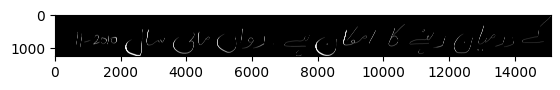

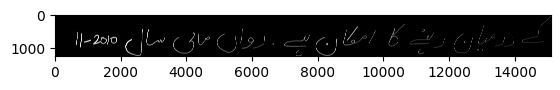

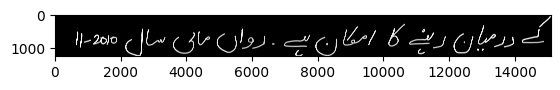

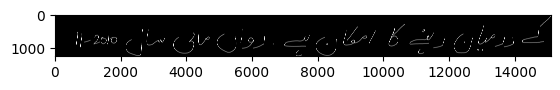

  0%|          | 1/2403 [00:08<5:43:30,  8.58s/it]


In [26]:
# Key based Image Generation
i = 0
for record in tqdm(df_main.itertuples(), total=len(df_main)):
    if i >= 1:
        break
    csv = pd.read_csv(record.csv)
    csv = csv.sort_values(by='Time')
    
    # for col in ['Pressure', 'X tilt', 'Y tilt', 'Height', 'Thickness']:
    for col in ['Pressure', 'X tilt', 'Y tilt', "Stroke"]:
        if col == "Stroke":
            scaled = np.zeros_like(csv["Pressure"].values) 
        else:
            scaled = scale(col, values=csv[col].values, stats=stats, feature_name=col, gamma=1.3, pressure_mask=csv["Pressure"].values > 0, alpha=1.3)
        
        
        # print(scaled.min(), scaled.max())
        if col != "Stroke":
            # draw_strokes(csv, col_to_linewidth(scaled, min_width=0.75, max_width=2.25), col_to_linewidth(scaled, min_width=0.3, max_width=1))
            canvas = draw_canvas(csv, col_to_linewidth(scaled, min_width=10, max_width=40), col_to_linewidth(scaled, min_width=0.3, max_width=1))
        else:
            # draw_strokes(csv, col_to_linewidth(scaled, min_width=0.75, max_width=2.25))
            canvas = draw_canvas(csv, col_to_linewidth(scaled, min_width=10, max_width=40))
        # plt.title(f'{col} Visualization', fontsize=16)
        
        name = record.csv.split('/')
        name[2] = f'img_{col}'
        os.makedirs('/'.join(name[:-1]), exist_ok=True)
        name = '/'.join(name)[:-4] + '.png'
        name = name.replace('csv', 'img')
        # plt.savefig(name, dpi=300, bbox_inches='tight', pad_inches=0)
        
        # cropped = tight_crop_img(name, thresh_val=254)
        # cv2.imwrite(name, cropped)
        # plt.clf()
        # plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        plt.imshow(canvas, cmap='gray')
        plt.show()
        # plt.axis('off')
        # plt.show()
        
        # plt.clf()
        # plt.hist(scaled[csv["Pressure"].values > 0], bins=50)
        # plt.title(f'{col} Scaled Distribution', fontsize=16)
        # plt.show()
    i+=1

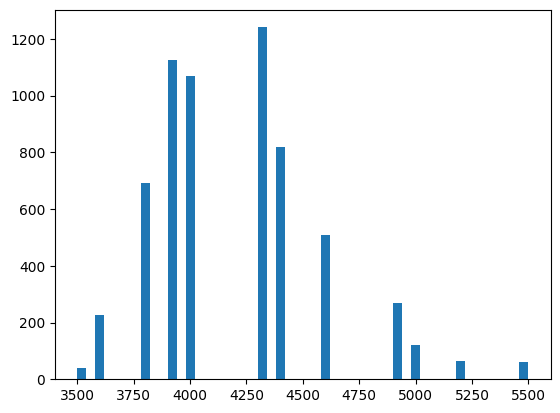

3500 5500 4188.446726572529 370.7597593478456


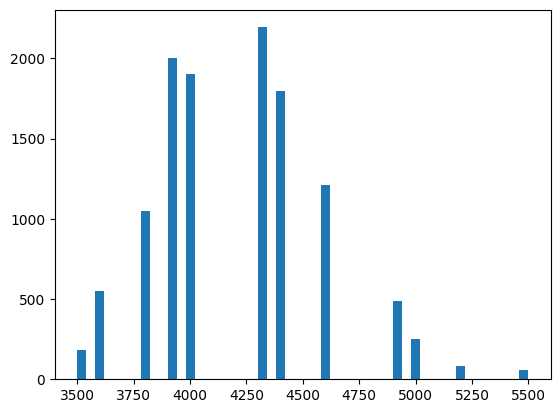

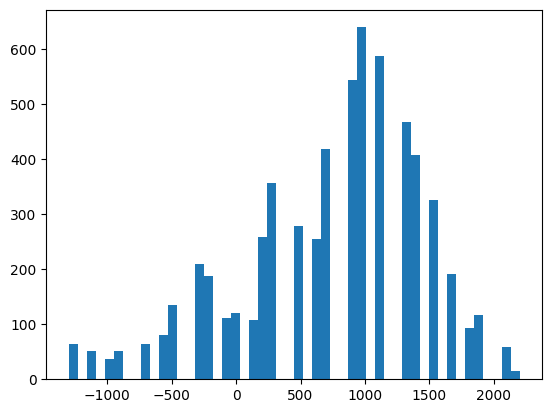

-1300 2200 733.071245186136 710.4137831711193


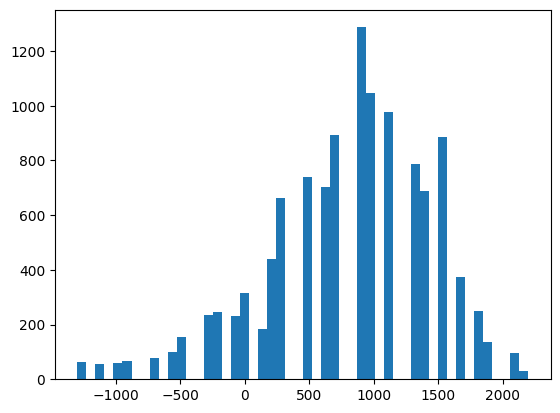

In [ ]:
# values = csv[csv["Pressure"] > 0]['Y tilt'].values
# plt.hist(values, bins=50)
# plt.show()

# print(values.min(), values.max(), values.mean(), values.std())

# values = csv['Y tilt'].values
# plt.hist(values, bins=50)
# plt.show()

# values = csv[csv["Pressure"] > 0]['X tilt'].values
# plt.hist(values, bins=50)
# plt.show()

# print(values.min(), values.max(), values.mean(), values.std())

# values = csv['X tilt'].values
# plt.hist(values, bins=50)
# plt.show()

0it [00:00, ?it/s]

0 2488 459.53103506835356 519.8903053535769
-1300 2200 792.2985480173219 644.2785124371911
3500 5500 4192.281565763777 367.11983272845674
-111 0 -4.166680818544621 13.552315790000712
0 336 183.2208542073533 167.30907207081896
0 2176 393.9346717130163 491.1440439973134
-1400 2500 971.1782129340135 729.3588069057809
3000 5500 4536.276123087049 386.255537493561
-117 0 -6.521556689155833 15.37279827439396


4it [00:00,  7.28it/s]

0 336 155.9466842191871 167.56705397746896
0 1824 325.2817676218111 405.57322447511524
-1500 2500 644.0515052593398 722.0255259481859
3000 5800 4477.862410833031 431.6849605224627
-115 0 -10.050417120058034 20.690749584602788
0 336 152.07544432354007 167.24356049339335
0 1671 266.2006357615894 381.2473368100574
-2100 2800 668.7841059602649 674.8283115567287
2700 5600 4531.814569536424 499.0558158536954
-111 0 -11.714437086092715 20.81046198416523
0 336 129.87846357615894 163.6176899381169


5it [00:00,  7.28it/s]


0 2312 346.730363092213 484.64096010490556
-1000 2500 686.7976734993506 645.7361462662959
2800 5600 4309.36811790615 496.39025787742025
-115 0 -11.43932463719013 22.03405243293037
0 336 143.8183974250381 166.2505642002655


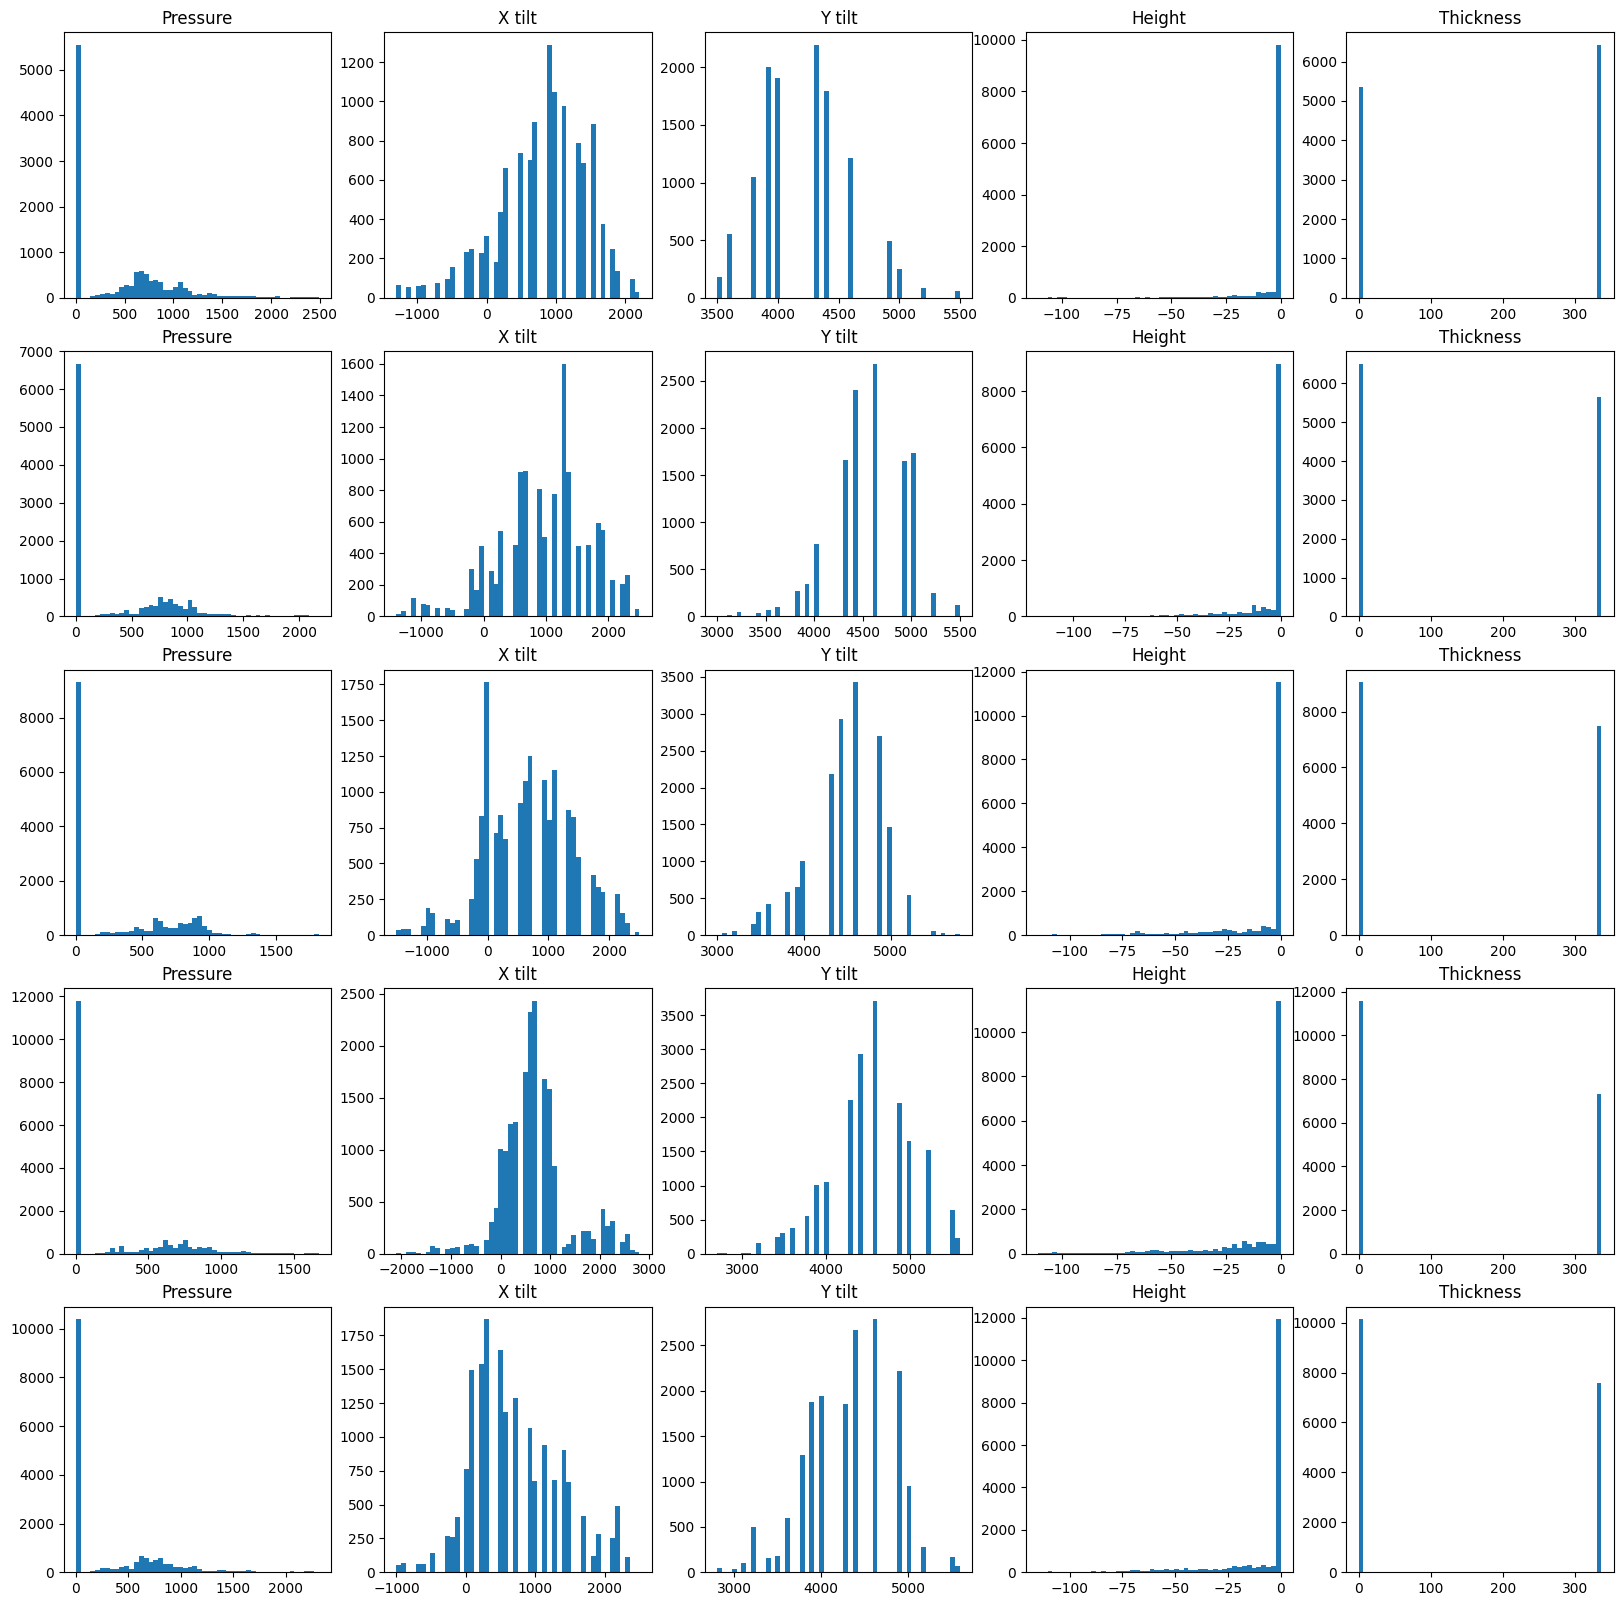

In [ ]:
# Key based Image Generation
i = 0
figure, axes = plt.subplots(5, 5, figsize=(20,20))
for record in tqdm(df_main.itertuples()):
    if i >= 5:
        break
    csv = pd.read_csv(record.csv)
    csv = csv.sort_values(by='Time')
    linewidths = scale(csv, scaler, gamma=100, min_width=1.5, max_width=7)
    for col in ['Pressure', 'X tilt', 'Y tilt', 'Height', 'Thickness']:
        values = csv[col].values
        axes_idx = ['Pressure', 'X tilt', 'Y tilt', 'Height', 'Thickness'].index(col)
        axes[i][axes_idx].hist(values, bins=50)
        axes[i][axes_idx].set_title(col)

        # plt.hist(values, bins=50)
        # plt.title(col)
        print(values.min(), values.max(), values.mean(), values.std())
    i+=1
plt.show() 